# Toxicity Fairness Analysis with Zero-Shot LLMs and Integrated Gradients

Zero-shot toxicity classification with Integrated Gradients explanations and fairness analysis across demographic identity groups for Responsible AI evaluation.

## Pipeline Overview
- Zero-shot toxicity/hate/offense classification using LLMs
- Integrated Gradients (IG) token attribution explanations
- Token-level attribution heatmap visualization
- Fairness metrics computation across demographic groups
- Dataset downloading utilities for social bias benchmarks

## Features
- Log-probability-based zero-shot classification (no fine-tuning required)
- Integrated Gradients for model interpretability
- Group fairness metrics (SPD, Equal Opportunity, worst-case)
- Resume-safe Parquet/CSV I/O
- GPU/CPU automatic device selection
<!-- ## File Overview
| File | Purpose |
|------|---------|
| `llm_zero_shot_explain.py` | Core zero-shot classification engine with Integrated Gradients explanations. |
| `fairness_metrics.py` | Computes per-group fairness metrics (Accuracy, F1, TPR, FPR, SPD, EOpp). |
| `download_data.py` | Download and normalize social bias datasets from Hugging Face. |
| `sample_jigsaw.py` | Convert Kaggle Jigsaw CSV to normalized Parquet format. | -->

## Download and Normalize Social-Problem Datasets

This notebook downloads, normalizes, and saves social-problem datasets (Jigsaw, Civil) into Parquet files.

Outputs are standardized with at least:
- `comment_text`
- `target`

In [1]:
# ===== Standard library =====
import importlib.util
import itertools
import random
from collections.abc import Generator, Iterator
from pathlib import Path
from typing import Any

# ===== Scientific stack =====
import numpy as np
import numpy.typing as npt
import pandas as pd

# ===== ML / DL =====
import torch
from torch.nn import functional
from transformers import AutoModelForCausalLM, AutoTokenizer

# ===== Datasets & metrics =====
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

# ===== Visualization & progress =====
import matplotlib.pyplot as plt
from rich.progress import track


/fs01/projects/aixpert/users/aravind/interpretability_agent_bootcamp/implementations/toxicity_fairness_analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.download_data import (
    load_civil,
    to_parquet  
)

In [3]:
# Configuration (edit interactively)
DATASET = "jigsaw" # jigsaw or civil
STREAM = True
TAKE = 50000 # for full data = 100000, 5_000 # for jigsaw = 50000
SAMPLE = None
DATA_DIR = f"./data/{DATASET}/"
OUT_PATH = f"./data/{DATASET}/{DATASET}.parquet"

In [4]:
def load_dataset(
    dataset_name,
    TAKE,
    DATA_DIR,
):
    """Load the dataset based on the dataset name and return a DataFrame."""
    if dataset_name == "civil":
        df = load_civil(stream=True, take=TAKE)
    
        if TAKE and len(df) > TAKE:
            df = df.sample(TAKE, random_state=42).reset_index(drop=True)
        return df

    if dataset_name == "jigsaw":
        df = pd.read_csv(f"{DATA_DIR}/train.csv")
        # Keep only the relevant columns
        COLS_KEEP = [
            "comment_text", "target", "severe_toxicity",
            "obscene", "identity_attack", "insult",
            "threat", "male", "female",
            "transgender", "other_gender", "heterosexual",
            "homosexual_gay_or_lesbian", "bisexual",
            "other_sexual_orientation", "christian",
            "jewish", "muslim", "hindu",
            "buddhist", "atheist", "other_religion",
            "black", "white", "asian", "latino", "other_race_or_ethnicity",
        ]

        df = df[COLS_KEEP].copy()

        if TAKE:
            df = df.sample(TAKE, random_state=42).reset_index(drop=True)

        return df

### Data Formats

### Input Datasets
Supported datasets via `download_data.py`:
- **CivilComments**: Toxicity labels with 7 toxicity sub-types

Expected columns:
```json
{
  "comment_text": "Text content to classify",
  "target": 0 or 1,  // binary toxicity label
  "severe_toxicity": 0.0-1.0,   // identity attribute scores
  "obscene": 0.0-1.0,
  "insult": 0.0-1.0,
  "thread": 0.0-1.0,
  // ... additional identity columns
}
```

In [5]:
# Load the dataset
df = load_dataset(DATASET,TAKE, DATA_DIR)
df.head()

,comment_text,target,severe_toxicity,obscene,identity_attack,insult,threat,male,female,transgender,...,muslim,hindu,buddhist,atheist,other_religion,black,white,asian,latino,other_race_or_ethnicity
0,What a breathe of fresh air to have someone wh...,0.166667,0.0,0.0,0.0,0.166667,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Your jewish friends were the ones who told you...,0.600000,0.2,0.0,0.6,0.400000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Possible collusion by Trump and his affiliates...,0.000000,0.0,0.0,0.0,0.000000,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Exactly. We need a % of GDP spending cap at t...,0.000000,0.0,0.0,0.0,0.000000,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"By your own comment, even if some of them vote...",0.000000,0.0,0.0,0.0,0.000000,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Run it only once to save as parquet (uncomment if needed)
# OUT_DIR = Path(f"./data/{DATASET}")
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# PARQUET_PATH = OUT_DIR / f"{DATASET}.parquet"
# df.to_parquet(PARQUET_PATH, index=False)

# print(f"Saved -> {PARQUET_PATH}")

In [5]:
# to_parquet(df, OUT_PATH) # Uncomment to save as parquet

Wrote 100,000 rows -> data/civil/civil.parquet


## Zero-shot LLM Toxicity Scoring with Integrated Gradients

Performs zero-shot binary classification on social-problem text
(e.g. toxicity, hate, offense) using a causal LLM, and computes
Integrated Gradients (IG) explanations over prompt tokens.

Key features:
- Zero-shot scoring via log-probability differences
- Integrated Gradients using `inputs_embeds`
- Optional float32 stability for LayerNorm
- Parquet/CSV-safe data loading

In [6]:
from src.llm_zero_shot_explain import (
    get_device,
    load_llm,
    score_and_predict,
    integrated_gradients,
    save_heatmap,
    load_df_safely,
)

In [7]:
# Define labels for each task
LABELS = {
    "toxicity": ["toxic", "non-toxic"],
    "hate": ["hateful", "not hateful"],
    "offense": ["offensive", "not offensive"],
}

In [8]:
# ---- User configuration ----
INPUT_PATH = f"./data/{DATASET}/{DATASET}.parquet"
TEXT_COL = "comment_text"
TASK = "toxicity"
MODEL_NAME = "distilgpt2"

MAX_ROWS = 1000
IG_ROWS = 25
IG_STEPS = 32
FORCE_FLOAT32 = True
SAVE_HEATMAPS = True

OUTPUT_PATH = f"./results/{DATASET}/zs_preds.parquet"


In [9]:
def run_scoring_with_explanations(
    df,
    text_col,
    model_name,
    task,
    input_path,
    dataset,
    max_rows=None,
    save_heatmaps=False,
    ig_rows=0,
    ig_steps=50,
    force_float32=False,
):
    """Run scoring with explanations on the given DataFrame."""
    df = df.copy()
    if max_rows is not None:
        df = df.iloc[:max_rows]

    device = get_device()
    # Load model and tokenizer
    model, tok = load_llm(model_name, device, force_float32=force_float32)

    preds = []
    ig_records = []

    # Create directory for heatmaps
    heatmap_dir = Path(f"./results/{dataset}/ig_heatmaps")
    heatmap_dir.mkdir(parents=True, exist_ok=True)

    # Iterate over DataFrame rows
    for i in track(range(len(df)), description="Scoring"):
        text = str(df.iloc[i][text_col])[:4096]

        res = score_and_predict(model, tok, text, task)

        preds.append({
            "idx": i,
            "pred": res["pred"],
            "score": res["score"],
            "lp_pos": res["lp_pos"],
            "lp_neg": res["lp_neg"],
        })

        if save_heatmaps and len(ig_records) < ig_rows:
            toks, atts, prompt = integrated_gradients(
                model, tok, text, task, steps=ig_steps
            )
            img_path = heatmap_dir / f"row{i}.png"
            save_heatmap(toks, atts, str(img_path))

            ig_records.append({
                "idx": i,
                "heatmap": str(img_path),
                "prompt": prompt,
            })

    return preds, ig_records

In [ ]:
# Load DataFrame safely and run scoring with explanations
df = load_df_safely(INPUT_PATH)
preds, ig_records = run_scoring_with_explanations(
    df=df,
    text_col=TEXT_COL,
    model_name=MODEL_NAME,
    task=TASK,
    input_path=INPUT_PATH,
    dataset=DATASET,
    max_rows=MAX_ROWS,
    save_heatmaps=SAVE_HEATMAPS,
    ig_rows=IG_ROWS,
    ig_steps=IG_STEPS,
    force_float32=FORCE_FLOAT32,
)

In [11]:
# Save predictions and IG records
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
pd.DataFrame(preds).to_parquet(OUTPUT_PATH, index=False)

# Save IG records if any
if ig_records:
    pd.DataFrame(ig_records).to_parquet(
        Path(OUTPUT_PATH).with_suffix(".ig.parquet"),
        index=False,
    )

print(f"Saved predictions -> {OUTPUT_PATH}")

Saved predictions -> ./results/jigsaw/zs_preds.parquet


## Fairness Metrics Across Demographic Groups

In [12]:
from src.fairness_metrics import (
    load_df,
    binarize_labels,
    metrics_for_group,
)

In [13]:
# Load predictions
df = pd.read_parquet(f"./results/{DATASET}/zs_preds.parquet")
print(df.columns.tolist())

['idx', 'pred', 'score', 'lp_pos', 'lp_neg']


In [16]:
# ===== CONFIG =====
PREDS_PATH = f"./results/{DATASET}/zs_preds.parquet"
LABELS_FILE = f"./data/{DATASET}/{DATASET}.parquet"
LABEL_COL = "target"
POSITIVE_LABEL = 1

# Define identity columns based on dataset
if DATASET == "civil":
    IDENTITY_COLS = [
        "severe_toxicity",
        "obscene",
        "identity_attack",
        "insult",
        "threat",
    ]
elif DATASET == "jigsaw":
    IDENTITY_COLS = [
        "male", "female", "black", "white",
        "muslim", "jewish", "christian",
    ]
MIN_GROUP_SIZE = 30
OUTPUT_PATH = f"./results/{DATASET}/fairness_report.csv"

In [17]:
def evaluate_fairness_by_identity(
    preds_path,
    labels_path,
    label_col,
    positive_label,
    identity_cols,
    min_group_size=50,
):
    """Evaluate fairness metrics by identity groups."""
    df_preds = load_df(preds_path)

    # Check for 'idx' column
    if "idx" not in df_preds.columns:
        raise ValueError("Predictions must contain 'idx' column.")

    # Merge with labels if provided
    if labels_path:
        df_labels = load_df(labels_path)
        if "idx" not in df_labels.columns:
            df_labels = (
                df_labels.reset_index()
                .rename(columns={"index": "idx"})
            )
        df = df_preds.merge(df_labels, on="idx", how="left")
    else:
        df = df_preds.copy()

    # Check for label column
    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found.")

    # Binarize true labels
    y_true = binarize_labels(
        df[label_col],
        positive_label=positive_label,
        threshold=0.5,
    )

    # Check for predictions column
    if "pred" not in df.columns:
        raise ValueError("Missing 'pred' column in predictions.")

    # Binarize predictions
    y_pred = df["pred"].astype(int).values

    rows = []
    per_identity = []

    # Evaluate metrics for each identity column
    for identity in identity_cols:
        if identity not in df.columns:
            print(f"[warn] identity column '{identity}' missing; skipping")
            continue

        membership = (
            pd.to_numeric(df[identity], errors="coerce")
            .fillna(0)
            .gt(0)
            .astype(int)
            .values
        )

        group_rows = []

        # Evaluate metrics for each group (0 and 1)
        for val in (0, 1):
            mask = membership == val
            n = int(mask.sum())

            if n < min_group_size:
                group_rows.append({
                    "identity": identity,
                    "group": f"{identity}={val}",
                    "n": n,
                    "skipped": True,
                })
                continue

            metrics = metrics_for_group(
                y_true[mask],
                y_pred[mask],
            )

            group_rows.append({
                "identity": identity,
                "group": f"{identity}={val}",
                "n": n,
                "skipped": False,
                **metrics,
            })

        # Calculate SPD and EOpp differences
        g0 = next(
            (r for r in group_rows if r["group"].endswith("=0") and not r["skipped"]),
            None,
        )
        g1 = next(
            (r for r in group_rows if r["group"].endswith("=1") and not r["skipped"]),
            None,
        )

        # Only compute if both groups are present
        if g0 and g1:
            per_identity.append({
                "identity": identity,
                "SPD": g1["pos_rate"] - g0["pos_rate"],
                "EOpp_diff": g1["tpr"] - g0["tpr"],
                "n_A0": g0["n"],
                "n_A1": g1["n"],
            })

        rows.extend(group_rows)

    return (
        pd.DataFrame(rows),
        pd.DataFrame(per_identity),
    )


In [18]:
# Run fairness evaluation
group_df, disparity_df = evaluate_fairness_by_identity(
    preds_path=PREDS_PATH,
    labels_path=LABELS_FILE,
    label_col=LABEL_COL,
    positive_label=POSITIVE_LABEL,
    identity_cols=IDENTITY_COLS,
    min_group_size=MIN_GROUP_SIZE,
)

In [19]:
def write_fairness_reports(
    rows,
    per_identity,
    output_path,
):
    """Write fairness reports to CSV files."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    # Save per-group metrics
    rep = rows if isinstance(rows, pd.DataFrame) else pd.DataFrame(rows)
    rep.to_csv(output_path, index=False)

    # Save per-identity disparities and summary
    has_per_identity = (
        per_identity is not None
        and (
            (isinstance(per_identity, pd.DataFrame) and not per_identity.empty)
            or (isinstance(per_identity, list) and len(per_identity) > 0)
        )
    )

    # Per-identity path
    pi_path = output_path.with_suffix(".per_identity.csv")

    # Save per-identity disparities
    if has_per_identity:
        pi = per_identity if isinstance(per_identity, pd.DataFrame) else pd.DataFrame(per_identity)
        pi.to_csv(pi_path, index=False)

        summary = pd.DataFrame([{
            "WorstAbsSPD": pi["SPD"].abs().max(),
            "WorstAbsEOpp": pi["EOpp_diff"].abs().max(),
            "WorstGroupAcc": rep.loc[~rep["skipped"], "acc"].min(),
            "WorstGroupF1": rep.loc[~rep["skipped"], "f1"].min(),
        }])
    else:
        summary = pd.DataFrame([{
            "WorstAbsSPD": np.nan,
            "WorstAbsEOpp": np.nan,
            "WorstGroupAcc": np.nan,
            "WorstGroupF1": np.nan,
        }])

    summary_path = output_path.with_suffix(".summary.csv")
    summary.to_csv(summary_path, index=False)

    # Print saved paths
    print("Saved:")
    print(" - Per-group metrics:", output_path)
    print(" - Per-identity disparities:", pi_path)
    print(" - Summary:", summary_path)


In [20]:
# Write fairness reports
write_fairness_reports(
    rows=group_df,
    per_identity=disparity_df,
    output_path=OUTPUT_PATH,
)

Saved:
 - Per-group metrics: results/jigsaw/fairness_report.csv
 - Per-identity disparities: results/jigsaw/fairness_report.per_identity.csv
 - Summary: results/jigsaw/fairness_report.summary.csv


## Stage 4 — Visualize Fairness Results

In this stage, we analyze whether the **zero-shot LLM toxicity classifier** exhibits systematic disparities across different **toxicity subtypes** present in the CivilComments dataset.

Rather than demographic identities (e.g., gender or religion), CivilComments provides **content-based subgroup labels** such as *insult*, *threat*, and *identity attack*. These can be treated as binary group indicators to evaluate fairness across different forms of toxic content.

### ⚖️ Fairness Metrics Used

#### **Statistical Parity Difference (SPD)**

$$
\text{SPD} = P(\hat{Y}=1 \mid A=1) - P(\hat{Y}=1 \mid A=0)
$$

**Interpretation**

* Measures whether the model predicts *toxicity* more often for comments **mentioning an identity**.
* SPD = 0 → parity
* SPD > 0 → identity-associated comments are flagged *more toxic*
* SPD < 0 → identity-associated comments are flagged *less toxic*

---

### **Equal Opportunity Difference (EOpp)**

$$
\text{EOpp} = \text{TPR}_{A=1} - \text{TPR}_{A=0}
$$

**Interpretation**

* Measures whether the model correctly detects *true toxic comments* at the same rate across groups.
* Sensitive to **false negatives** for protected identities.
* Non-zero values indicate uneven error rates.

In [21]:
# Define output paths
OUTPUT_DIR = Path(f"results/{DATASET}")
SUMMARY_PATH = OUTPUT_DIR / "fairness_report.summary.csv"
PER_IDENTITY_PATH = OUTPUT_DIR / "fairness_report.per_identity.csv"

The table below summarizes the **worst observed disparities** across all toxicity subtypes:

* **WorstAbsSPD**: largest absolute statistical parity difference
* **WorstAbsEOpp**: largest absolute equal opportunity difference
* **WorstGroupAcc / WorstGroupF1**: lowest performance among all groups

These values help identify whether *any* subgroup experiences disproportionately poor or biased treatment.

In [22]:
# Load and display summary report
summary_df = pd.read_csv(SUMMARY_PATH)
summary_df

,WorstAbsSPD,WorstAbsEOpp,WorstGroupAcc,WorstGroupF1
0,0.047452,0.160714,0.755102,0.0


### 🧩 Per-Identity (Subtype) Fairness Breakdown

For each toxicity subtype (e.g., `identity_attack`, `insult`, `threat`), we compute:

* **SPD**: difference in predicted toxicity rate
* **EOpp_diff**: difference in true positive rates
* **n_A0 / n_A1**: group sizes (absence vs presence of subtype)

This breakdown allows us to localize where disparities arise instead of relying only on aggregate statistics.


In [23]:
# Load and display per-identity report
pi = pd.read_csv(PER_IDENTITY_PATH)
pi

,identity,SPD,EOpp_diff,n_A0,n_A1
0,male,0.011610,-0.160714,951,49
1,female,0.047452,-0.152542,956,44
2,christian,0.024130,0.114407,965,35


### 📈 Visualization: Statistical Parity Difference (SPD)

The bar chart below visualizes **SPD per toxicity subtype**.

* Each bar corresponds to one subtype (e.g., *identity_attack*).
* The horizontal dashed line at 0 indicates **perfect statistical parity**.
* Positive SPD values mean the model predicts *toxicity* more often when that subtype is present.

This visualization makes it easy to identify which forms of toxic content are most strongly associated with biased predictions.

<Figure size 800x400 with 0 Axes>

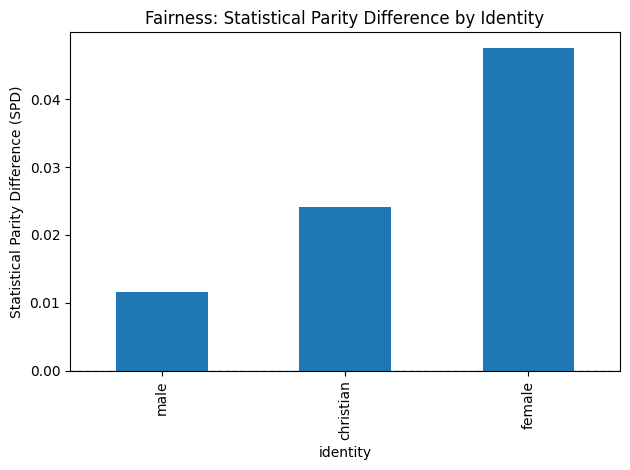

Saved -> results/jigsaw/jigsaw_SPD.png


In [24]:
# Plot Statistical Parity Difference (SPD) by identity
plt.figure(figsize=(8, 4))
pi.sort_values("SPD").plot(
    x="identity",
    y="SPD",
    kind="bar",
    legend=False,
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Statistical Parity Difference (SPD)")
plt.title("Fairness: Statistical Parity Difference by Identity")
plt.tight_layout()

out_path = OUTPUT_DIR / f"{DATASET}_SPD.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved -> {out_path}")

### 🧠 Interpretation and Takeaways (Civil dataset)

From the results:

* Certain subtypes (e.g., **identity_attack** and **severe_toxicity**) show noticeably higher SPD values.
* This suggests the zero-shot LLM is **more likely to flag toxicity** when these patterns are present, even controlling for the overall label.
* Such behavior may reflect:

  * Model sensitivity to strong lexical cues
  * Training data biases inherited by the language model
  * Over-generalization from certain toxic patterns

Importantly, this analysis does **not** imply intent or malice, but highlights where **model behavior differs systematically across content subgroups**.

### 🧠 Interpretation and Takeaways (Jigsaw dataset)

In this run:

* *female* shows the largest positive SPD
* *male* shows a smaller but non-zero disparity
* *christian* lies in between

This suggests the model is **more likely to flag comments referencing certain identities as toxic**, even without explicit ground-truth justification.

#### Key takeaways:
* The zero-shot LLM exhibits **measurable fairness disparities** on Jigsaw.
* Disparities are **identity-dependent**, not uniform.
* Even without fine-tuning, **prompt-based toxicity classification can amplify bias**.
* These results motivate:
  * Prompt calibration
  * Post-hoc thresholding
  * Explanation-based audits (e.g., Integrated Gradients)

### 🔍 Relation to Interpretability

In earlier stages, we computed **Integrated Gradients explanations** for selected examples. Combining those explanations with fairness results allows us to:

* Inspect *which tokens* drive high toxicity scores in high-SPD subgroups
* Diagnose whether explanations differ qualitatively across subtypes
* Bridge **fairness evaluation** with **model interpretability**

This closes the loop between *what the model predicts*, *how fairly it behaves*, and *why it makes those predictions*.